In [1]:
# Credit Card Dataset 


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA

In [4]:
df = pd.read_csv("D:\\advancedML\\Datasets\\Credit Card Customer Data.csv")
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


In [6]:
# Select features for clustering (removing ID columns)
X = df.drop(['Sl_No', 'Customer Key'], axis=1)

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier inspection if needed
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1.740187,-1.249225,-0.860451,-0.547490,-1.251537
1,0.410293,-0.787585,-1.473731,2.520519,1.891859
2,0.410293,1.058973,-0.860451,0.134290,0.145528
3,-0.121665,0.135694,-0.860451,-0.547490,0.145528
4,1.740187,0.597334,-1.473731,3.202298,-0.203739


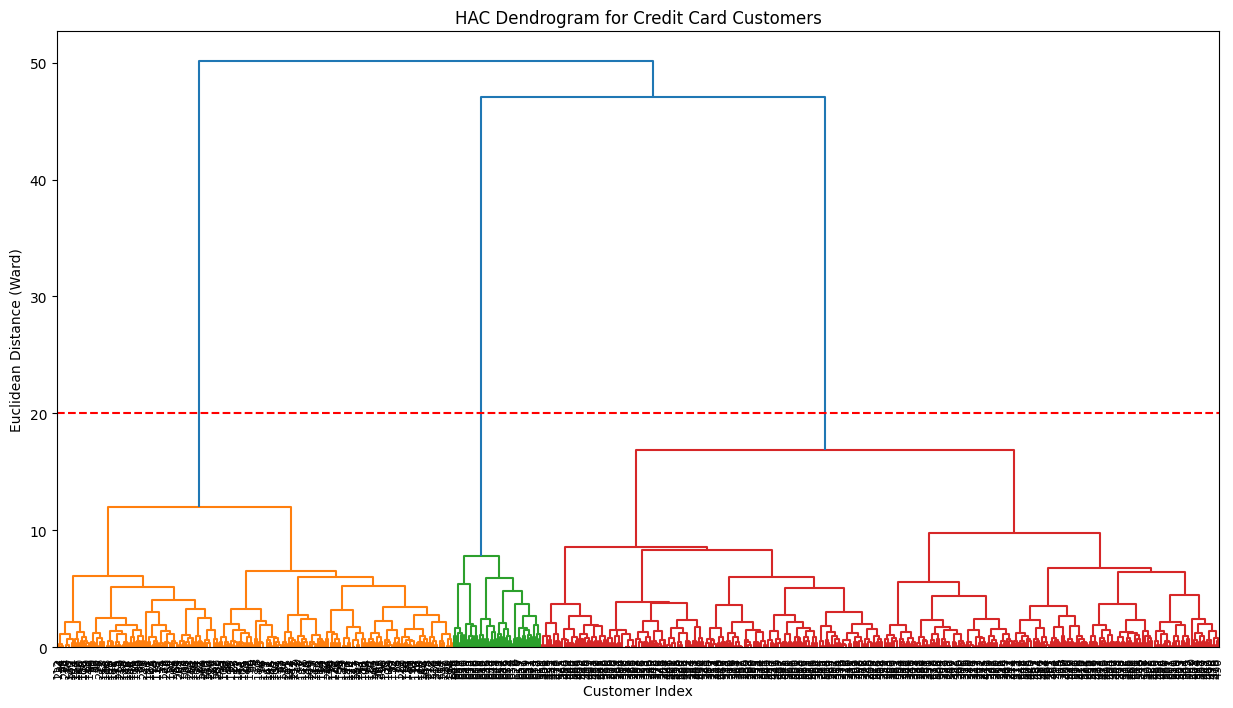

In [7]:
# Generate the linkage matrix
Z = linkage(X_scaled, method='ward')

# Plot the Dendrogram
plt.figure(figsize=(15, 8))
dendrogram(Z, leaf_rotation=90, leaf_font_size=8)
plt.title('HAC Dendrogram for Credit Card Customers')
plt.xlabel('Customer Index')
plt.ylabel('Euclidean Distance (Ward)')
plt.axhline(y=20, color='r', linestyle='--') # Optional: Visual guide for a cut-off point
plt.show()

For k=2, Silhouette Score: 0.4177
For k=3, Silhouette Score: 0.5148
For k=4, Silhouette Score: 0.3481
For k=5, Silhouette Score: 0.2569
For k=6, Silhouette Score: 0.2268
For k=7, Silhouette Score: 0.2163
For k=8, Silhouette Score: 0.2187
For k=9, Silhouette Score: 0.1953
For k=10, Silhouette Score: 0.1931


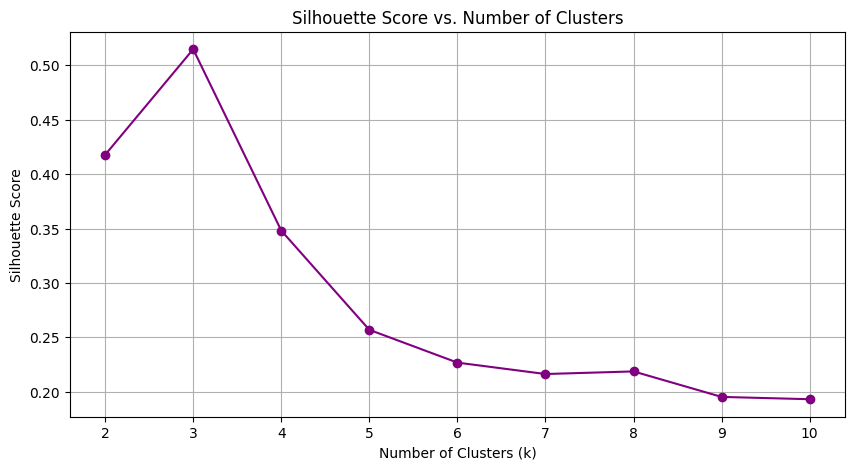

In [8]:
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    hac_model = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    labels = hac_model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"For k={k}, Silhouette Score: {score:.4f}")

# Plot Silhouette Scores
plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_scores, marker='o', color='purple')
plt.title('Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

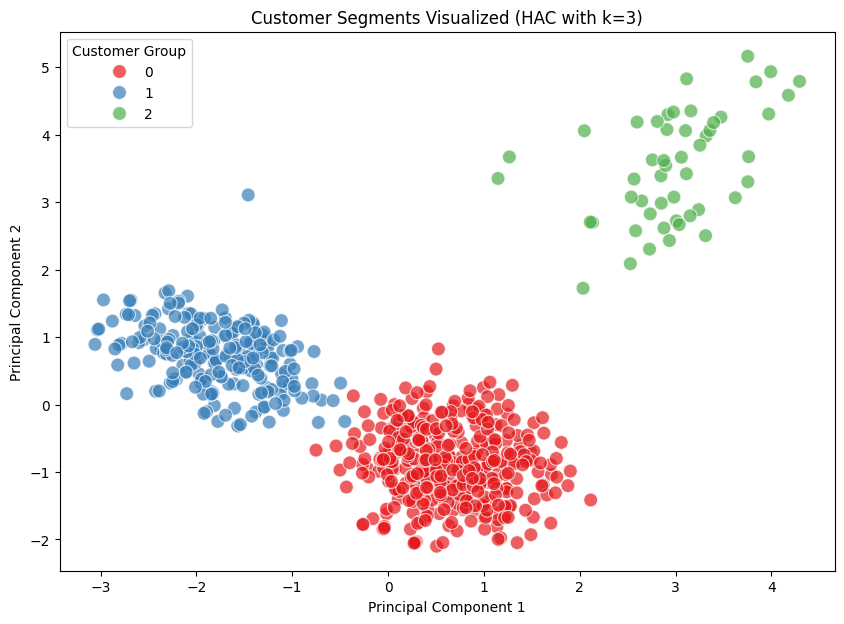

In [9]:
# Fit the final model (using k=3 based on typical optimal score for this data)
final_k = 3
hac_final = AgglomerativeClustering(n_clusters=final_k, metric='euclidean', linkage='ward')
df['Cluster'] = hac_final.fit_predict(X_scaled)

# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster'], palette='Set1', s=100, alpha=0.7)
plt.title(f'Customer Segments Visualized (HAC with k={final_k})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Customer Group')
plt.show()

Cluster Profiles (Mean Values):


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
Cluster,,,,,
0,33851.948052,5.516883,3.493506,0.979221,1.994805
1,12151.111111,2.422222,0.937778,3.546667,6.857778
2,141040.000000,8.740000,0.600000,10.900000,1.080000


C:\Users\ASUS\AppData\Local\Temp\ipykernel_6304\1359349723.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cluster', data=df, palette='Set1')


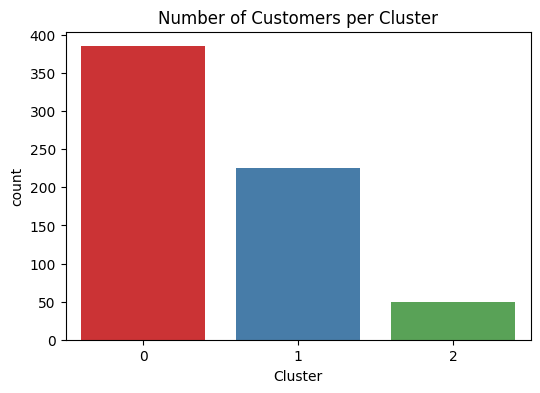

In [10]:
# Analyze the characteristics of each cluster
cluster_summary = df.drop(['Sl_No', 'Customer Key'], axis=1).groupby('Cluster').mean()
print("Cluster Profiles (Mean Values):")
display(cluster_summary)

# Visualizing the distribution of clusters
plt.figure(figsize=(6, 4))
sns.countplot(x='Cluster', data=df, palette='Set1')
plt.title('Number of Customers per Cluster')
plt.show()